## Project - Apple Stock Market Analysis

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

stock = pd.read_csv('/content/sample_data/AAPL (2).csv')
stock

,Date,Open,High,Low,Close,Adj Close,Volume
0,03-01-2012,58.485714,58.928570,58.428570,58.747143,50.765709,75555200
1,04-01-2012,58.571430,59.240002,58.468571,59.062859,51.038536,65005500
2,05-01-2012,59.278572,59.792858,58.952858,59.718571,51.605175,67817400
3,06-01-2012,59.967144,60.392857,59.888573,60.342857,52.144630,79573200
4,09-01-2012,60.785713,61.107143,60.192856,60.247143,52.061932,98506100
...,...,...,...,...,...,...,...
2006,23-12-2019,280.529999,284.250000,280.369995,284.000000,282.054138,24643000
2007,24-12-2019,284.690002,284.890015,282.920013,284.269989,282.322266,12119700
2008,26-12-2019,284.820007,289.980011,284.700012,289.910004,287.923645,23280300
2009,27-12-2019,291.119995,293.970001,288.119995,289.799988,287.814392,36566500


## Data cleaning, EDA & visualization

In [ ]:
stock['Date'] = pd.to_datetime(stock['Date'], format='%d-%m-%Y', dayfirst=True) # Specify the correct format for parsing (dayfirst=True handles single-digit days/months)
stock.set_index('Date', inplace=True)

In [ ]:
stock.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2011 entries, 2012-01-03 to 2019-12-30
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       2011 non-null   float64
 1   High       2011 non-null   float64
 2   Low        2011 non-null   float64
 3   Close      2011 non-null   float64
 4   Adj Close  2011 non-null   float64
 5   Volume     2011 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 110.0 KB


In [ ]:
stock.isnull().sum()

,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


In [ ]:
stock.shape

(2011, 7)

In [ ]:
stock.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2011.000000,2011.000000,2011.000000,2011.000000,2011.000000,2.011000e+03
mean,126.707469,127.827594,125.580258,126.741235,119.505548,5.949670e+07
std,50.483753,50.926301,50.124940,50.578369,52.438444,4.683856e+07
min,55.424286,57.085712,55.014286,55.790001,48.921928,1.136200e+07
25%,85.882858,86.717858,85.056427,86.202145,75.056679,2.758565e+07
50%,113.050003,114.190002,111.870003,113.050003,105.222908,4.346900e+07
75%,165.190002,167.409996,163.424995,165.245002,160.047111,7.471030e+07
max,291.119995,293.970001,288.119995,291.519989,289.522614,3.765300e+08


In [ ]:
# Pearson Correlation Coefficient
corr = stock.corr(method='pearson')
print(corr)

               Open      High       Low     Close  Adj Close    Volume
Open       1.000000  0.999782  0.999718  0.999496   0.998895 -0.557956
High       0.999782  1.000000  0.999657  0.999748   0.999171 -0.554909
Low        0.999718  0.999657  1.000000  0.999769   0.999179 -0.563426
Close      0.999496  0.999748  0.999769  1.000000   0.999402 -0.559654
Adj Close  0.998895  0.999171  0.999179  0.999402   1.000000 -0.566332
Volume    -0.557956 -0.554909 -0.563426 -0.559654  -0.566332  1.000000


In [ ]:
# Convert 'Date' column to datetime
if 'Date' in stock.columns:
    stock['Date'] = pd.to_datetime(stock['Date'])
    stock.set_index('Date', inplace=True)

In [ ]:
stock.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2011 entries, 2012-01-03 to 2019-12-30
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       2011 non-null   float64
 1   High       2011 non-null   float64
 2   Low        2011 non-null   float64
 3   Close      2011 non-null   float64
 4   Adj Close  2011 non-null   float64
 5   Volume     2011 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 110.0 KB


In [ ]:
stock.columns

Index(['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

In [ ]:
stock

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2012-01-03,58.485714,58.928570,58.428570,58.747143,50.765709,75555200
2012-01-04,58.571430,59.240002,58.468571,59.062859,51.038536,65005500
2012-01-05,59.278572,59.792858,58.952858,59.718571,51.605175,67817400
2012-01-06,59.967144,60.392857,59.888573,60.342857,52.144630,79573200
2012-01-09,60.785713,61.107143,60.192856,60.247143,52.061932,98506100
...,...,...,...,...,...,...
2019-12-23,280.529999,284.250000,280.369995,284.000000,282.054138,24643000
2019-12-24,284.690002,284.890015,282.920013,284.269989,282.322266,12119700
2019-12-26,284.820007,289.980011,284.700012,289.910004,287.923645,23280300


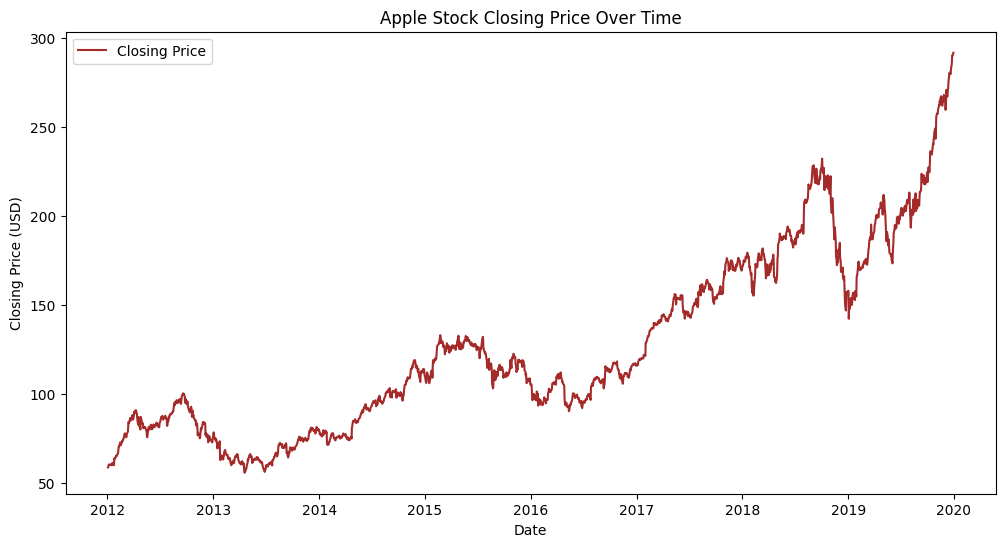

In [ ]:
# Plot closing price over time
plt.figure(figsize=(12, 6))
plt.plot(stock['Close'], label='Closing Price', color='brown')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.title('Apple Stock Closing Price Over Time')
plt.legend()
plt.show()

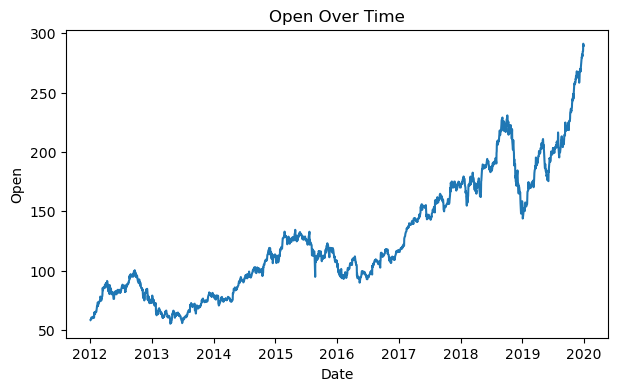

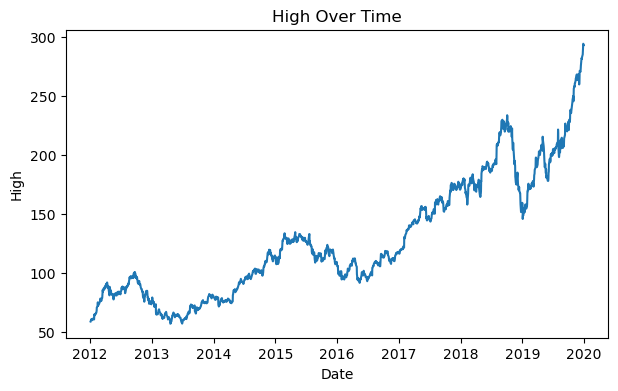

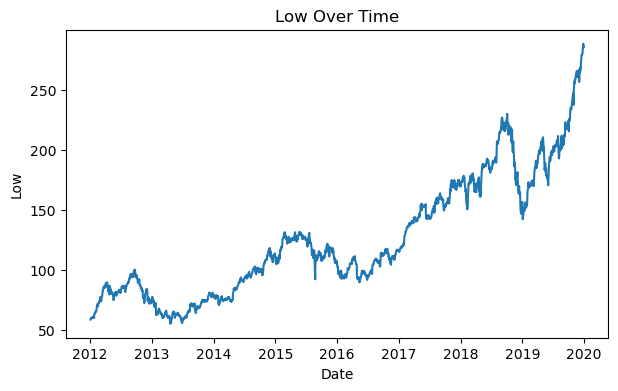

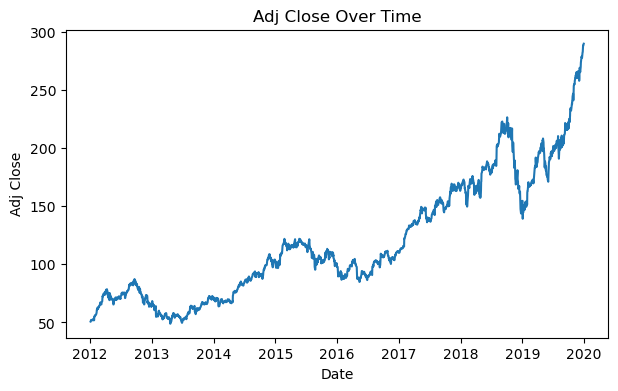

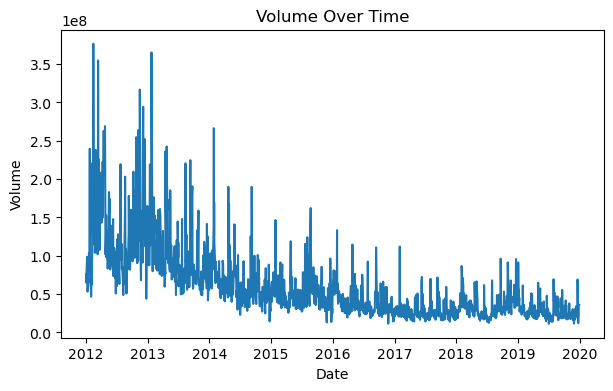

In [ ]:
features = ['Open', 'High', 'Low', 'Adj Close', 'Volume']
data=stock
for col in features:
    plt.figure(figsize=(7, 4))
    sns.lineplot(data=data, x=data.index, y=col)
    plt.title(f"{col} Over Time")
    plt.xlabel('Date')
    plt.ylabel(col)
    plt.show()

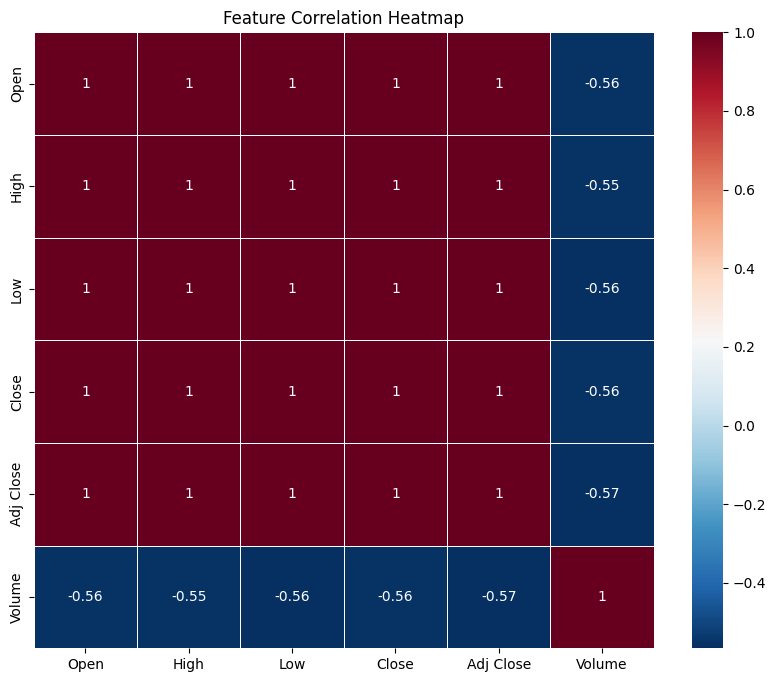

In [ ]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
corr_visual = sns.heatmap(corr,xticklabels=corr.columns, yticklabels=corr.columns,cmap='RdBu_r', annot=True, linewidth=0.7)
plt.title("Feature Correlation Heatmap")
plt.show()

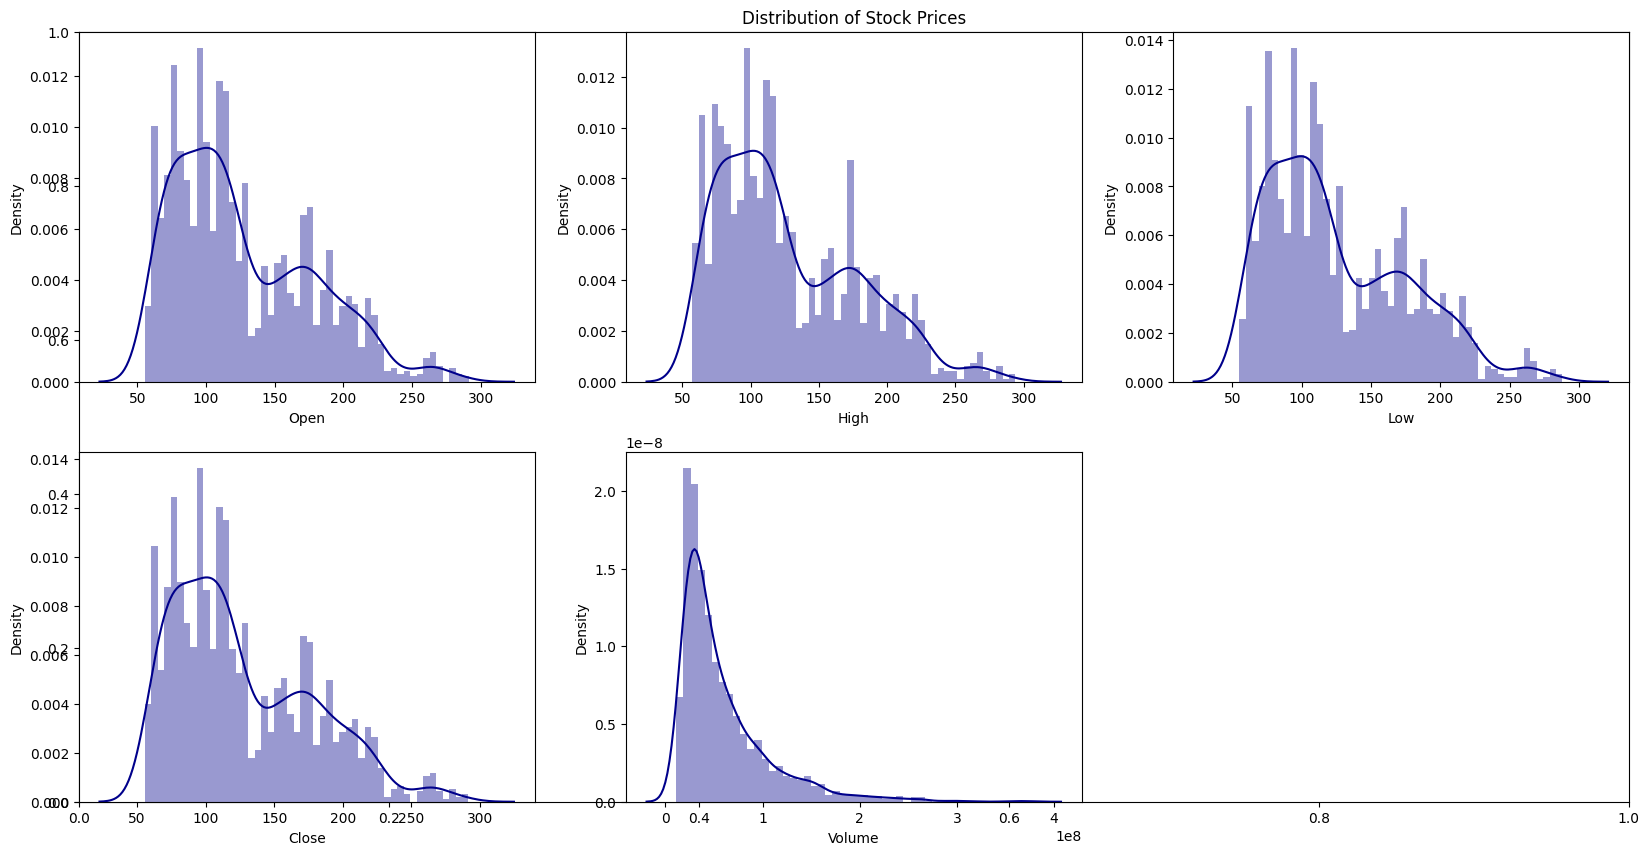

In [ ]:
features = ['Open', 'High', 'Low', 'Close', 'Volume']

plt.subplots(figsize=(20,10))
plt.title("Distribution of Stock Prices")
for i, col in enumerate(features):
  plt.subplot(2,3,i+1)
  sns.distplot(stock[col],bins=50, kde=True, color='darkblue')
plt.show()

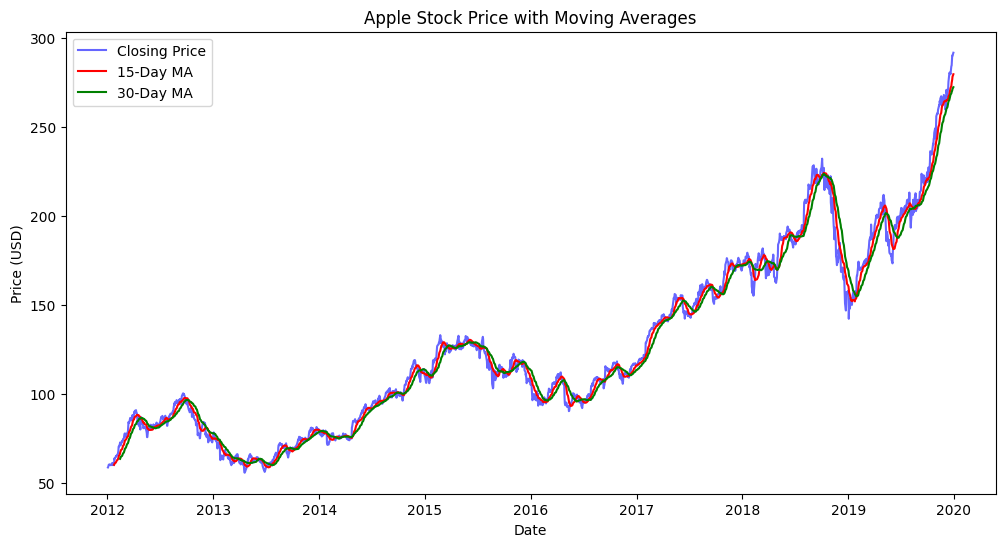

In [ ]:
# Moving Averages (for trend analysis)
stock['15_MA'] = stock['Close'].rolling(window=15).mean()
stock['30_MA'] = stock['Close'].rolling(window=30).mean()

# Plot Moving Averages with Closing Price
plt.figure(figsize=(12, 6))
plt.plot(stock['Close'], label='Closing Price', color='blue', alpha=0.6)
plt.plot(stock['15_MA'], label='15-Day MA', color='red')
plt.plot(stock['30_MA'], label='30-Day MA', color='green')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.title('Apple Stock Price with Moving Averages')
plt.legend()
plt.show()

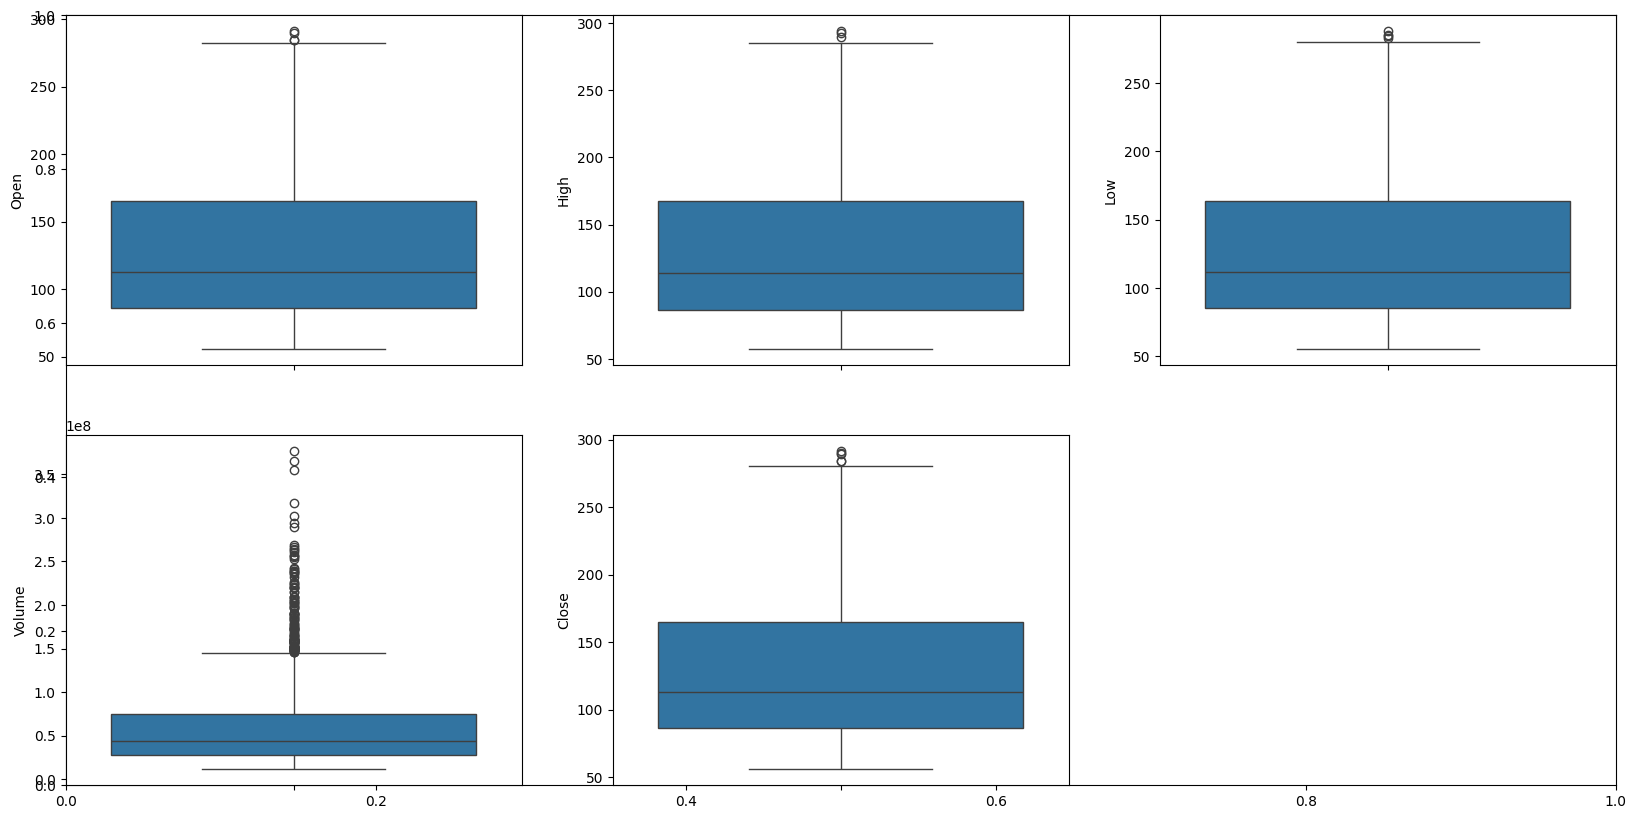

In [ ]:
features = ['Open', 'High', 'Low', 'Volume', 'Close']
plt.subplots(figsize=(20,10))
for i, col in enumerate(features):
  plt.subplot(2,3,i+1)
  sns.boxplot(stock[col])
plt.show()


In [ ]:
#Treating outlier of the data by mean
def replace_outliers_igr(stock, column):
    # Calculate Q1 (25th percentile) and Q3 (75th percentile)
    Q1 = stock[column].quantile(0.25)
    Q3 = stock[column].quantile(0.75)

    # Compute IQR
    IQR = Q3 - Q1

    # Define lower and upper bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR


    #Replace values below the lower bound with 01 and above the upper bound with 03
    stock [column] = stock [column].apply(lambda x: lower_bound if x < lower_bound else upper_bound if x> upper_bound else x)


#Example usage: Replace outliers in each numeric column
for col in stock.select_dtypes(include=['float64', 'int64']).columns:
    replace_outliers_igr(stock, col)


# Check if outliers are replaced
print(stock.describe())

              Open         High          Low        Close    Adj Close  \
count  2011.000000  2011.000000  2011.000000  2011.000000  2011.000000   
mean    126.700762   127.821977   125.571780   126.731064   119.504224   
std      50.462440    50.908326    50.098207    50.546104    52.434179   
min      55.424286    57.085712    55.014286    55.790001    48.921928   
25%      85.882858    86.717858    85.056427    86.202145    75.056679   
50%     113.050003   114.190002   111.870003   113.050003   105.222908   
75%     165.190002   167.409996   163.424995   165.245002   160.047111   
max     284.150718   288.448204   280.977848   283.809289   287.532761   

             Volume        15_MA        30_MA  
count  2.011000e+03  1997.000000  1982.000000  
mean   5.652610e+07   126.424311   126.120020  
std    3.727814e+07    49.621028    48.716831  
min    1.136200e+07    58.770952    60.068000  
25%    2.758565e+07    85.898096    85.788476  
50%    4.346900e+07   112.794001   112.912333

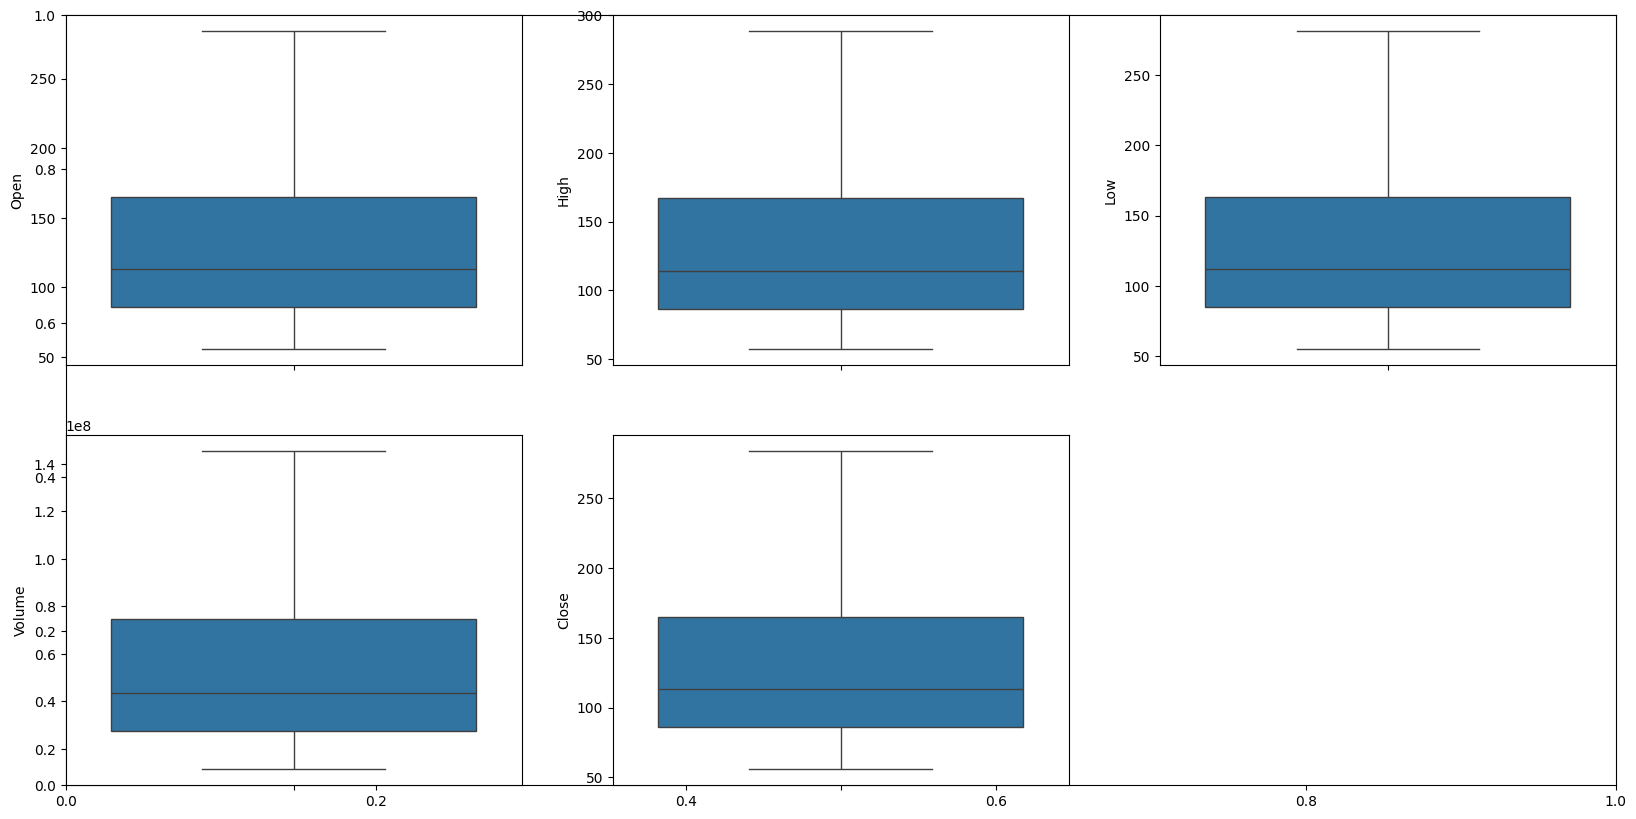

In [ ]:
features = ['Open', 'High', 'Low', 'Volume', 'Close']
plt.subplots(figsize=(20,10))
for i, col in enumerate(features):
  plt.subplot(2,3,i+1)
  sns.boxplot(stock[col])
plt.show()

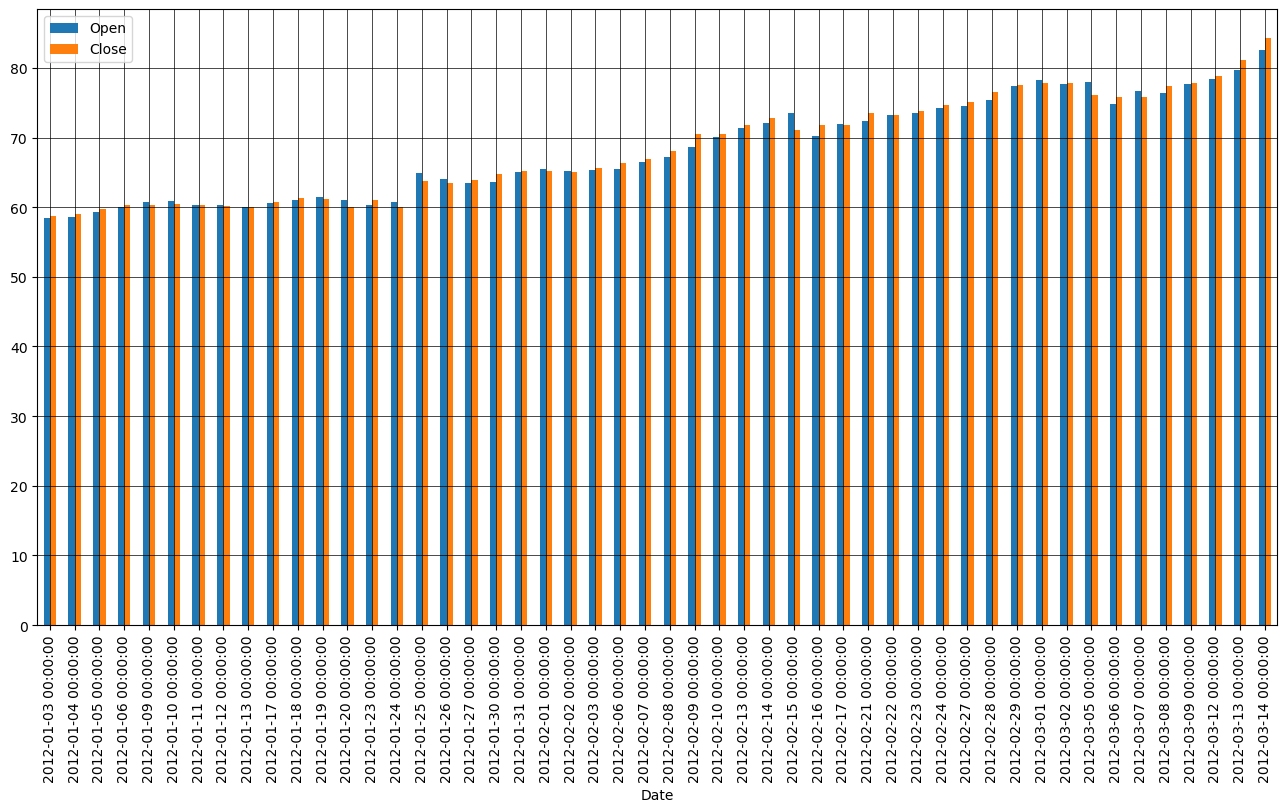

In [ ]:
# Plot Open vs Close (Year 2012)
stock[['Open','Close']].head(50).plot(kind='bar',figsize=(16,8))
plt.grid(which='major', linestyle='-', linewidth='0.5', color='black')
plt.grid(which='minor', linestyle=':', linewidth='0.5', color='yellow')
plt.show()

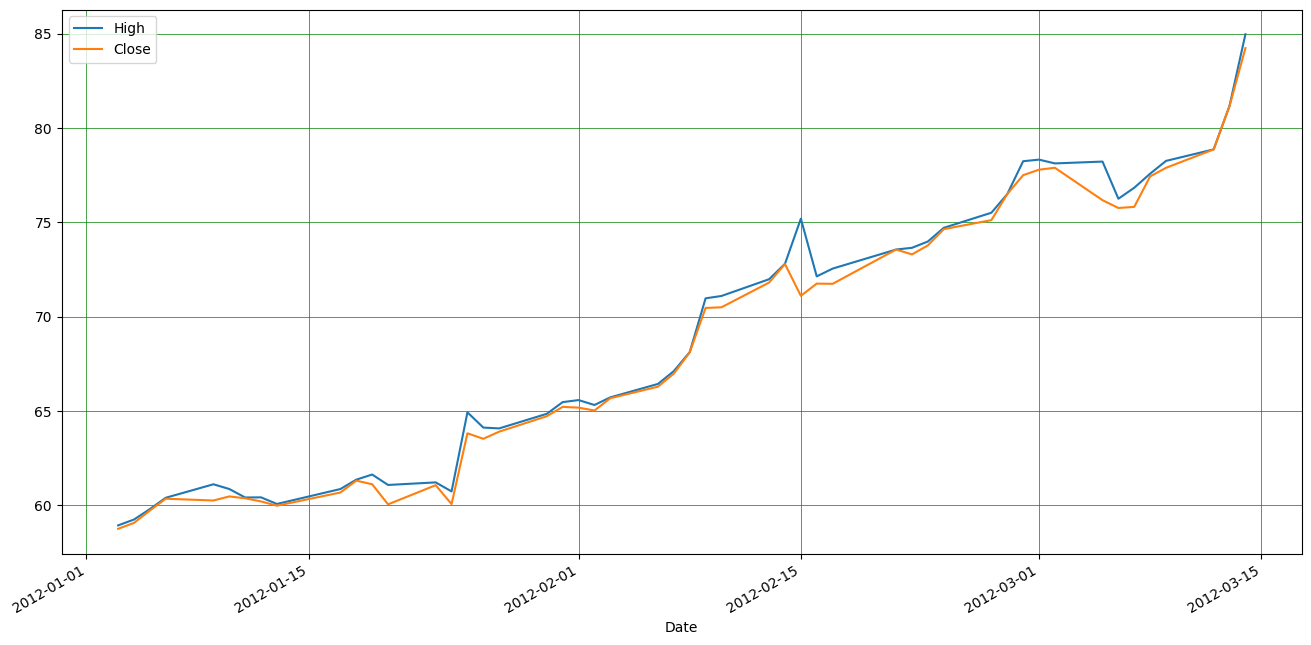

In [ ]:
# Plot High vs Close (Year 2012)
stock[['High','Close']].head(50).plot(kind='line',figsize=(16,8))
plt.grid(which='major', linestyle='-', linewidth='0.5', color='green')
plt.grid(which='minor', linestyle=':', linewidth='0.5', color='black')
plt.show()

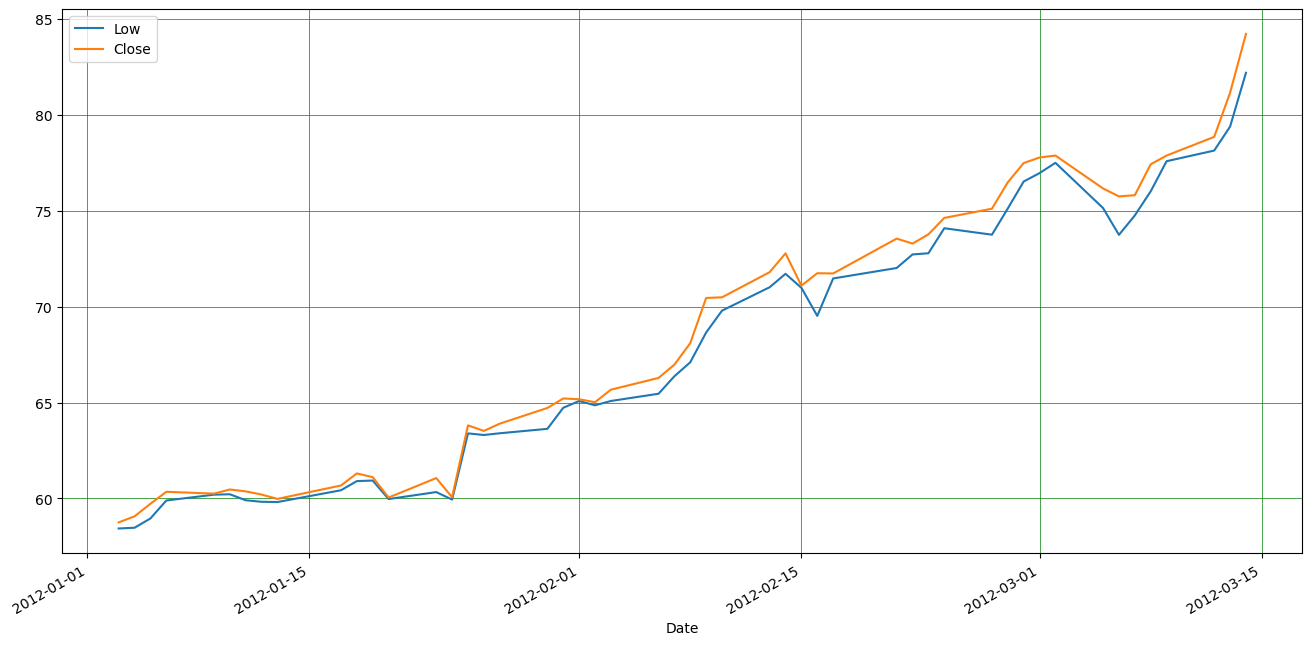

In [ ]:
# Plot Low vs Close (Year 2012)
stock[['Low','Close']].head(50).plot(kind='line',figsize=(16,8))
plt.grid(which='major', linestyle='-', linewidth='0.5', color='green')
plt.grid(which='minor', linestyle=':', linewidth='0.5', color='black')
#plt.show()

In [ ]:
stock.columns

Index(['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', '15_MA',
       '30_MA'],
      dtype='object')

In [ ]:
# Add new features: Month and Year
stock['Month'] = stock.index.month
stock['Year'] = stock.index.year

# Feature Engineering
stock['EMA_20'] = stock['Close'].ewm(span=20, adjust=False).mean()  # Exponential Moving Average
stock['Daily_Return'] = stock['Close'].pct_change()   # Cumulative Returns
stock['Cumulative_Return'] = (1 + stock['Daily_Return']).cumprod()

stock['Volatility'] = (stock['High'] - stock['Low']) / stock['Open']  # Volatility (based on High-Low)

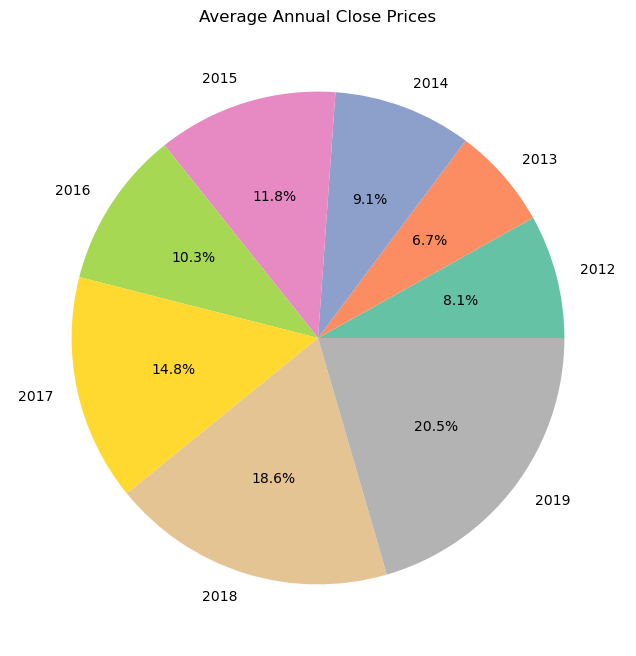

In [ ]:
# Pie chart of average annual close prices
annual_avg = stock.groupby('Year')['Close'].mean()
plt.figure(figsize=(8, 8))
plt.pie(annual_avg, labels=annual_avg.index, autopct='%1.1f%%', colors=sns.color_palette('Set2'))
plt.title("Average Annual Close Prices")
plt.show()

<Figure size 1000x600 with 0 Axes>

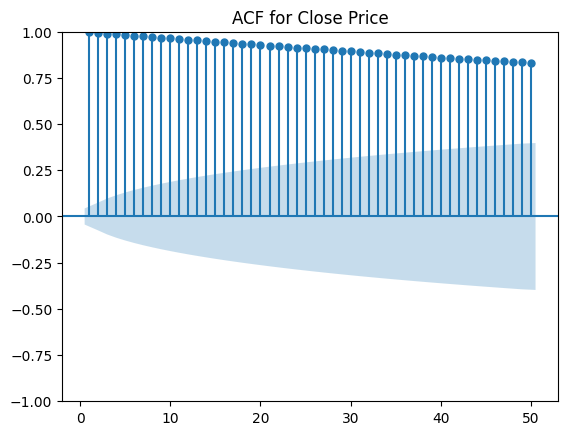

<Figure size 1000x600 with 0 Axes>

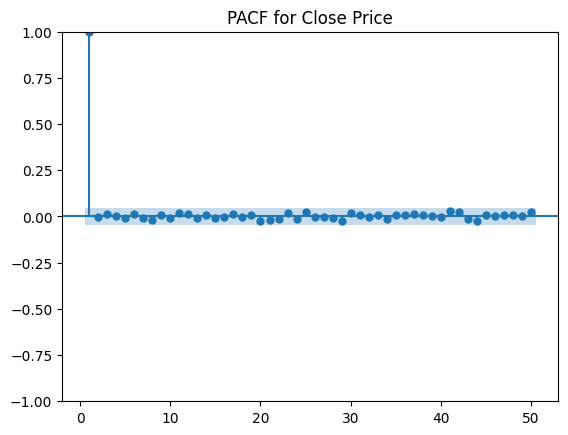

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF
plt.figure(figsize=(10, 6))
plot_acf(stock['Close'], lags=50, title='ACF for Close Price', zero=False)
plt.show()

# Plot PACF
plt.figure(figsize=(10, 6))
plot_pacf(stock['Close'], lags=50, title='PACF for Close Price', zero=False)
plt.show()

Correlation with Target Variable: Close        1.000000
Low          0.999771
High         0.999747
Open         0.999498
Adj Close    0.999395
15_MA        0.995998
30_MA        0.990578
Volume      -0.624962
Name: Close, dtype: float64


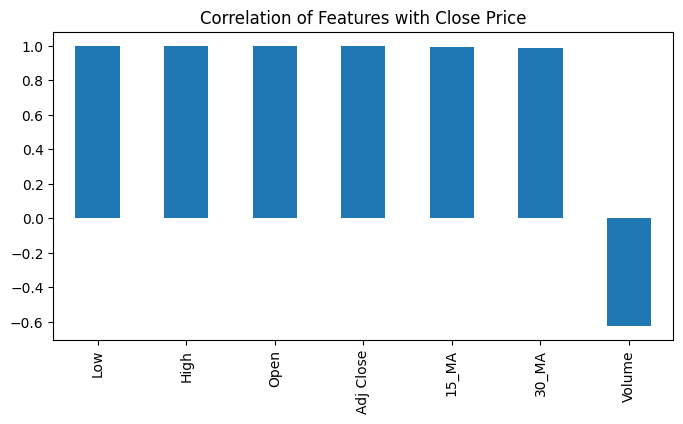

In [ ]:
# Calculate correlation of features with the target variable
correlation_with_target = stock.corr()['Close'].sort_values(ascending=False)
print("Correlation with Target Variable:", correlation_with_target)

correlation_with_target.drop('Close').plot(kind='bar', figsize=(8, 4))
plt.title("Correlation of Features with Close Price")
plt.show()

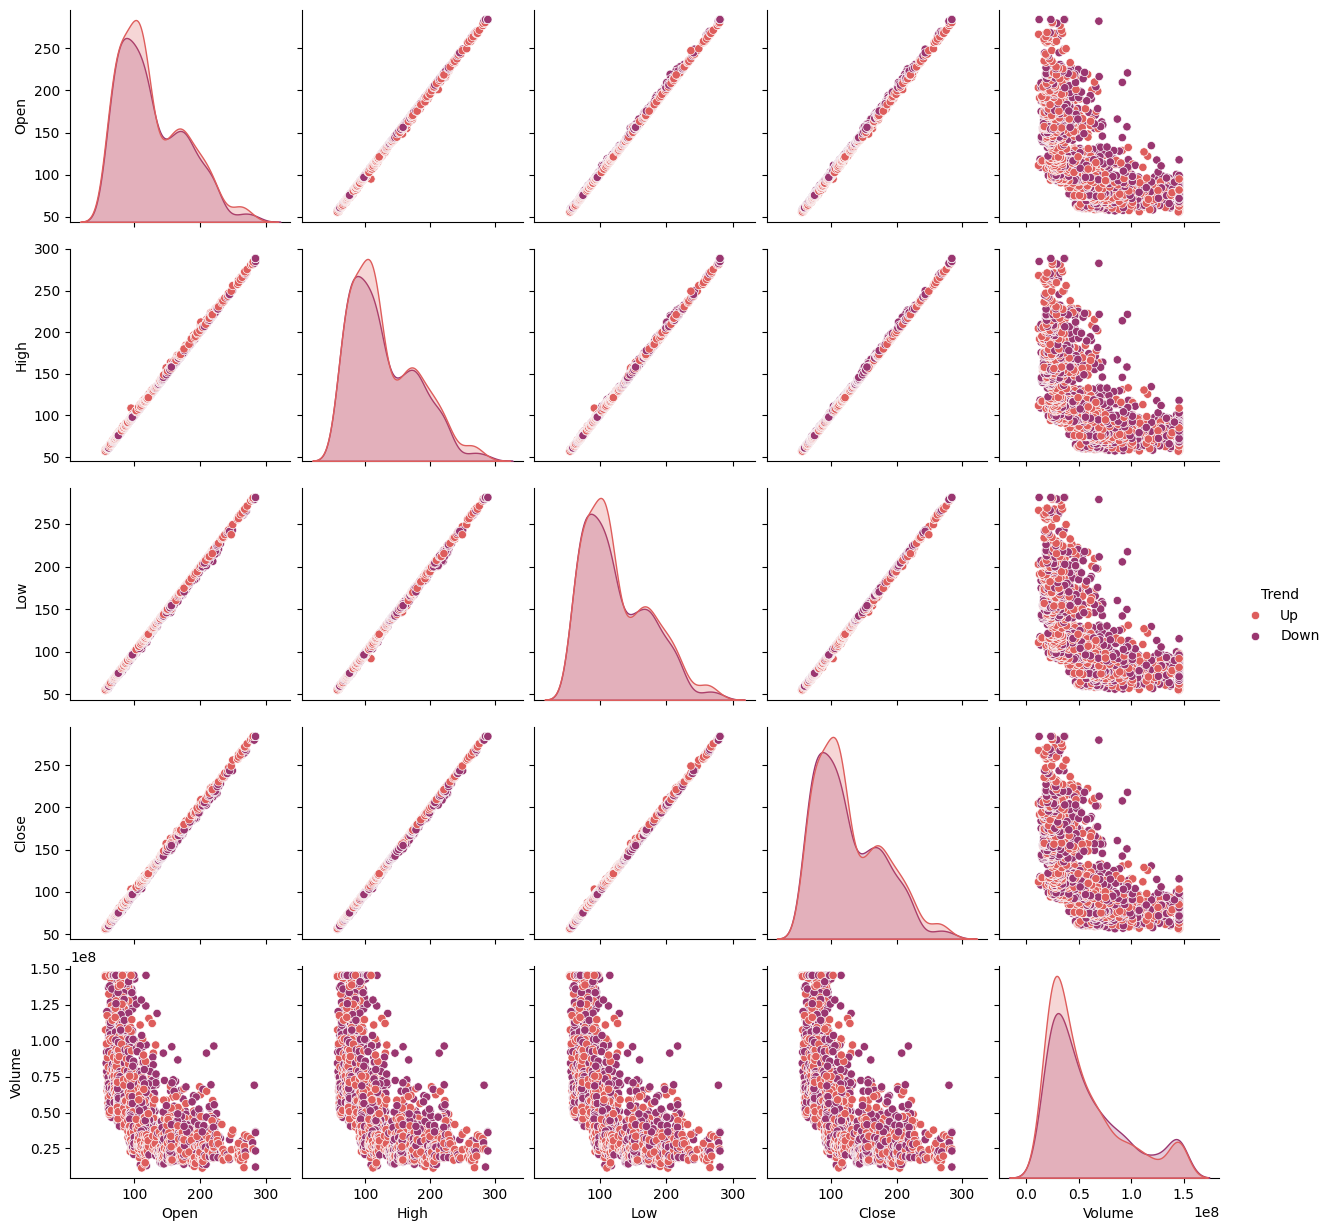

In [ ]:
#  Creating a categorical variable (e.g., price trend)
stock['Trend'] = ['Up' if close > open else 'Down' for open, close in zip(stock['Open'], stock['Close'])]

# Creating the pairplot with a color palette
sns.pairplot(stock[['Open', 'High', 'Low', 'Close', 'Volume', 'Trend']], hue='Trend', palette='flare')

plt.show()

In [ ]:
# calculate skewness and Kurtosis
skewness = stock['Close'].skew()
kurtosis = stock['Close'].kurt()

print('Skewness:', skewness)
print('Kurtosis:', kurtosis)

Skewness: 0.7698429924296034
Kurtosis: -0.1729163495869872


In [ ]:
monthly_data = stock.drop(columns=['Trend']).resample('M').mean() # Exclude the 'Trend' column
monthly_data

,Open,High,Low,Close,Adj Close,Volume,15_MA,30_MA
Date,,,,,,,,
2012-01-31,61.251428,61.572643,60.830072,61.225428,52.907298,8.103912e+07,60.994651,NaN
2012-02-29,70.686143,71.549857,70.205357,71.081572,61.424381,1.164437e+08,67.049733,65.764407
2012-03-31,82.408312,83.152077,81.463701,82.501104,71.292448,1.374077e+08,78.659429,74.538171
2012-04-30,87.086785,87.926786,85.521428,86.571857,74.810151,1.415918e+08,87.171343,84.628295
2012-05-31,80.826429,81.734481,79.771039,80.667597,69.708045,1.207329e+08,81.951125,84.118500
...,...,...,...,...,...,...,...,...
2019-08-31,205.262274,207.609546,202.849546,204.957728,202.738817,3.095794e+07,205.151424,204.666000
2019-09-30,217.727499,219.471001,215.939500,217.994999,215.853332,2.712836e+07,213.522333,209.559766
2019-10-31,234.929565,236.969131,232.945218,235.286521,232.974974,2.644794e+07,228.233623,222.817536


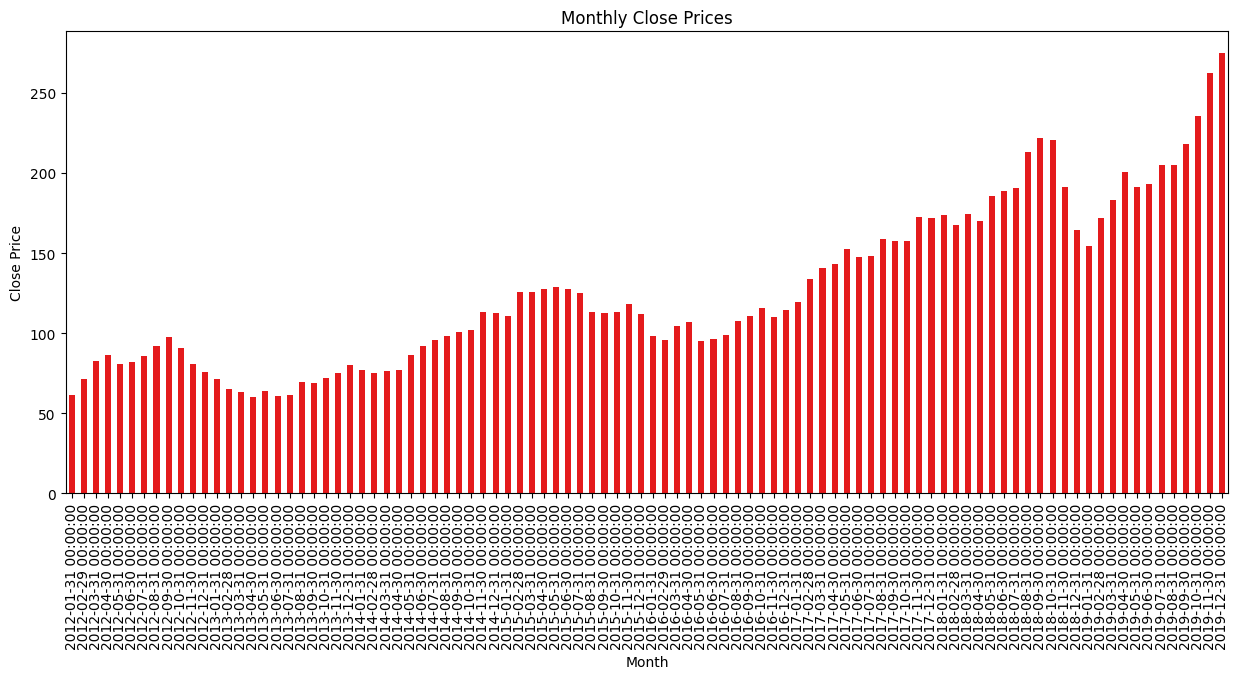

In [ ]:
# Plot for closing monthly stocks.
monthly_data['Close'].plot(kind='bar', figsize=(15,6), colormap='Set1')


plt.title("Monthly Close Prices")
plt.xlabel("Month")
plt.ylabel("Close Price")
plt.show()

In [ ]:
stock.columns

Index(['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', '15_MA', '30_MA',
       'Trend'],
      dtype='object')

1) volatility: a tendency to change quickly and unpredictably.
2) Trend: a general change or development.
3) EMA_20: Exponential Moving Average.
4) 15MA,30MA: 15 and 30 days moving average.
5) Cumulative_return: is the total gain or loss of an investment over a period of time.

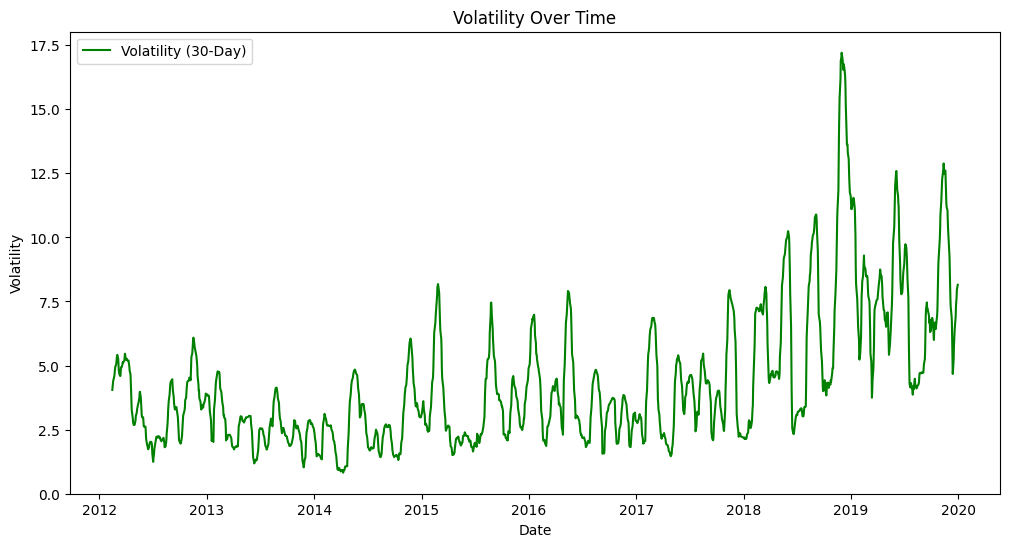

In [ ]:
## Volatility (Rolling Std Dev)
stock['Volatility'] = stock['Close'].rolling(window=30).std()
plt.figure(figsize=(12, 6))
plt.plot(stock['Volatility'], label='Volatility (30-Day)', color='green')
plt.title('Volatility Over Time')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.show()

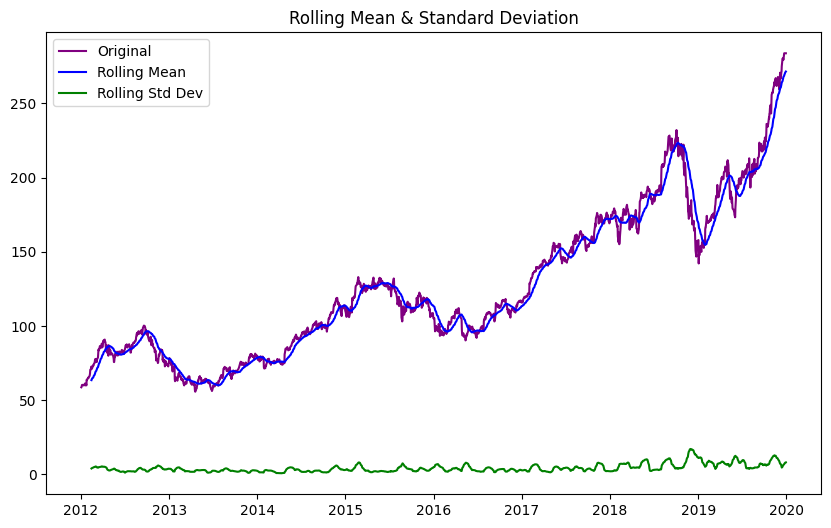

In [ ]:
rolling_mean = stock['Close'].rolling(window=30).mean()
rolling_std = stock['Close'].rolling(window=30).std()

plt.figure(figsize=(10, 6))
plt.plot(stock['Close'], label='Original', color='purple')
plt.plot(rolling_mean, label='Rolling Mean', color='blue')
plt.plot(rolling_std, label='Rolling Std Dev', color='green')
plt.legend()
plt.title('Rolling Mean & Standard Deviation')
plt.show()

## Model Building

1) MinMax Scalar convert the data points with range of 0 & 1
2) Applying the fit transform to the array.

## Train Test split

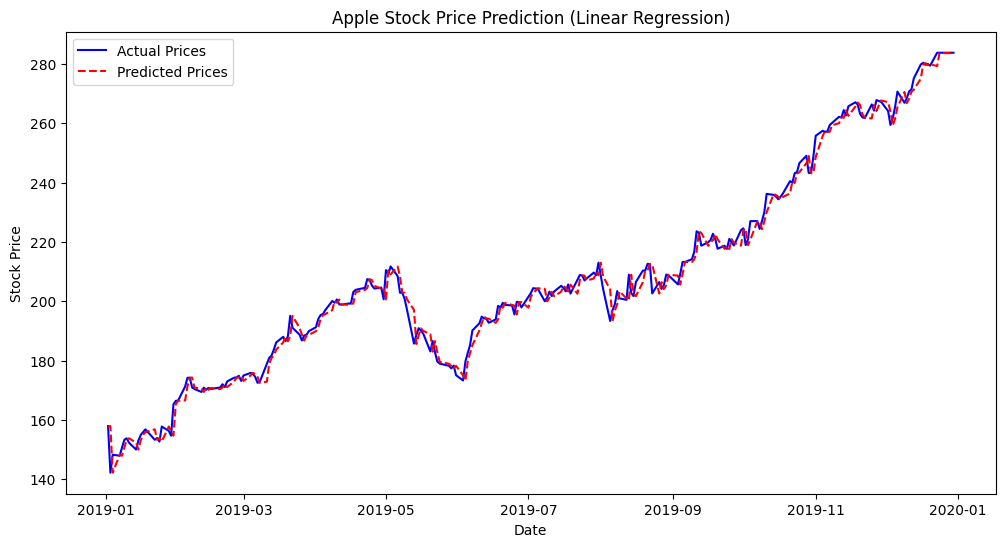

In [ ]:

import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression


# Create lag features
stock['Lag_1'] = stock['Close'].shift(1)
stock['Lag_7'] = stock['Close'].shift(7)

# Drop missing values
stock.dropna(inplace=True)

# Split stock into train (2012-2018) and test (2019)
train = stock.loc['2012-01-01':'2018-12-31']
test = stock.loc['2019-01-01':]

X_train = train[['Lag_1', 'Lag_7']]
y_train = train['Close']
X_test = test[['Lag_1', 'Lag_7']]
y_test = test['Close']

# Scale the features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predict on test set
y_pred_lr = lr_model.predict(X_test_scaled)

# Plot Actual vs Predicted Prices
plt.figure(figsize=(12, 6))
plt.plot(test.index, y_test, label="Actual Prices", color="blue")
plt.plot(test.index, y_pred_lr, label="Predicted Prices", color="red", linestyle="dashed")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.title("Apple Stock Price Prediction (Linear Regression)")
plt.legend()
plt.show()


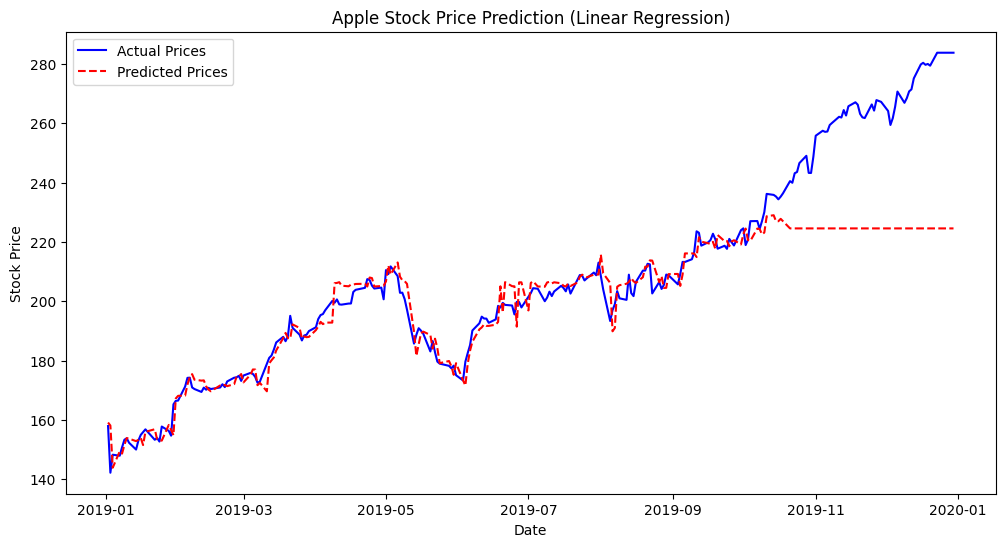

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Predict on test set
y_pred_rf = rf_model.predict(X_test_scaled)

# Plot Actual vs Predicted Prices
plt.figure(figsize=(12, 6))
plt.plot(test.index, y_test, label="Actual Prices", color="blue")
plt.plot(test.index, y_pred_rf, label="Predicted Prices", color="red", linestyle="dashed")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.title("Apple Stock Price Prediction (Linear Regression)")
plt.legend()
plt.show()

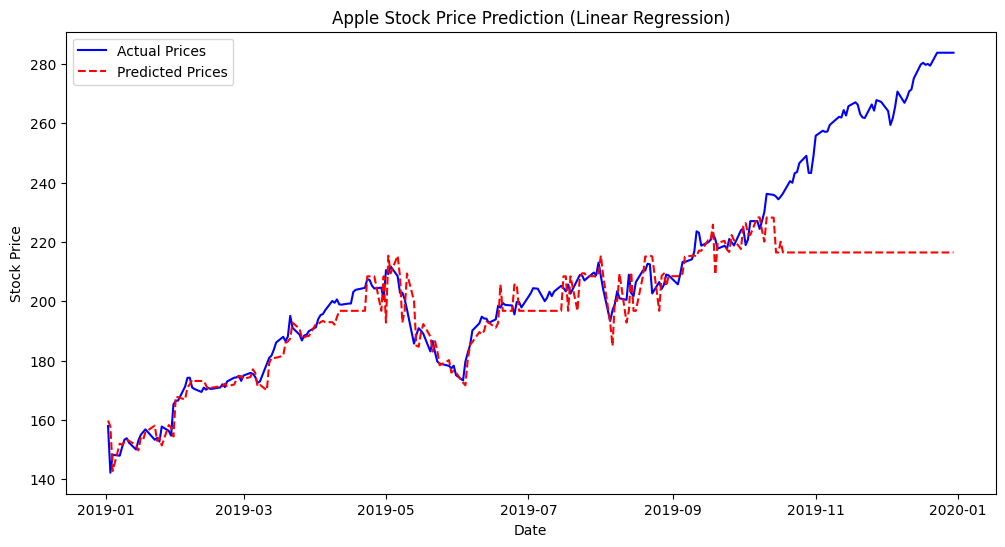

In [ ]:
import xgboost as xgb

# XGBoost
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100)
xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)

# Plot Actual vs Predicted Prices
plt.figure(figsize=(12, 6))
plt.plot(test.index, y_test, label="Actual Prices", color="blue")
plt.plot(test.index, y_pred_xgb, label="Predicted Prices", color="red", linestyle="dashed")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.title("Apple Stock Price Prediction (Linear Regression)")
plt.legend()
plt.show()

In [47]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

# Assuming 'stock' DataFrame is already loaded and 'Date' is the index
data = stock['Close']

# Example: Assuming you've identified p=5, d=1, q=2 from ACF/PACF analysis
p = 5
d = 1
q = 2

# Create and fit the ARIMA model
model = ARIMA(data, order=(p, d, q))
model_fit = model.fit()

# Predict for the same period as the test set
# Get the start and end dates of the test set
start_date = test.index.min()
end_date = test.index.max()

# Generate predictions for the test set period
predictions = model_fit.predict(start=start_date, end=end_date)

# Now, 'predictions' should have the same length as 'y_test'

# ... (Rest of your code remains the same)

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [48]:
from sklearn.metrics import mean_absolute_error, mean_squared_error


# Evaluation metrics function
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"{model_name} Evaluation Metrics:")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAPE: {mape:.2f}%\n")
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

# Evaluate all models
metrics_lr = evaluate_model(y_test, y_pred_lr, 'Linear Regression')
metrics_rf = evaluate_model(y_test, y_pred_rf, 'Random Forest')
metrics_xgb = evaluate_model(y_test, y_pred_xgb, 'XGBoost')
from sklearn.metrics import mean_squared_error
metrics_arima=evaluate_model(y_test, predictions, 'ARIMA')

# Combine results
results = pd.DataFrame([metrics_lr, metrics_rf, metrics_xgb,metrics_arima])
print("Overall Model Comparison:")
print(results)

Linear Regression Evaluation Metrics:
MAE: 2.33
RMSE: 3.24
MAPE: 1.16%

Random Forest Evaluation Metrics:
MAE: 10.35
RMSE: 18.70
MAPE: 4.24%

XGBoost Evaluation Metrics:
MAE: 12.65
RMSE: 22.33
MAPE: 5.18%

ARIMA Evaluation Metrics:
MAE: 2.31
RMSE: 3.20
MAPE: 1.15%

Overall Model Comparison:
               Model        MAE       RMSE      MAPE
0  Linear Regression   2.333997   3.235279  1.159882
1      Random Forest  10.350487  18.699647  4.237601
2            XGBoost  12.650272  22.333381  5.177167
3              ARIMA   2.309230   3.196936  1.152004


In [ ]:
print(X_train.shape), print(y_train.shape)

(1731, 2)
(1731,)


(None, None)

In [ ]:
print(X_test.shape), print(y_test.shape)

(251, 2)
(251,)


(None, None)

## Creating a stacked LSTM model

In [49]:
## ------------------------------

In [ ]:
df1=stock.reset_index()['Close']

from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(0,1))
df1=scaler.fit_transform(np.array(df1).reshape(-1,1))

##splitting dataset into train and test split
training_size=int(len(df1)*0.65)
test_size=len(df1)-training_size
train_data,test_data=df1[0:training_size,:],df1[training_size:len(df1),:1]

import numpy
# convert an array of values into a dataset matrix
def create_dataset(dataset, time_step=1):
	dataX, dataY = [], []
	for i in range(len(dataset)-time_step-1):
		a = dataset[i:(i+time_step), 0]   ###i=0, 0,1,2,3-----99   100
		dataX.append(a)
		dataY.append(dataset[i + time_step, 0])
	return numpy.array(dataX), numpy.array(dataY)
# reshape into X=t,t+1,t+2,t+3 and Y=t+4
time_step = 100
X_train, y_train = create_dataset(train_data, time_step)
X_test, ytest = create_dataset(test_data, time_step)

# reshape input to be [samples, time steps, features] which is required for LSTM
X_train =X_train.reshape(X_train.shape[0],X_train.shape[1] , 1)
X_test = X_test.reshape(X_test.shape[0],X_test.shape[1] , 1)
### Create the Stacked LSTM model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM
model=Sequential()
model.add(LSTM(50,return_sequences=True,input_shape=(100,1)))
model.add(LSTM(50,return_sequences=True))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(loss='mean_squared_error',optimizer='adam')

model.fit(X_train,y_train,validation_data=(X_test,ytest),epochs=100,batch_size=64,verbose=1)
### Lets Do the prediction and check performance metrics
train_predict=model.predict(X_train)
test_predict=model.predict(X_test)
##Transformback to original form
train_predict=scaler.inverse_transform(train_predict)
test_predict=scaler.inverse_transform(test_predict)
### Calculate RMSE performance metrics
import math
from sklearn.metrics import mean_squared_error
math.sqrt(mean_squared_error(y_train,train_predict))

math.sqrt(mean_squared_error(ytest,test_predict))
### Plotting
# shift train predictions for plotting
look_back=100
trainPredictPlot = numpy.empty_like(df1)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[look_back:len(train_predict)+look_back, :] = train_predict
# shift test predictions for plotting
testPredictPlot = numpy.empty_like(df1)
testPredictPlot[:, :] = numpy.nan
testPredictPlot[len(train_predict)+(look_back*2)+1:len(df1)-1, :] = test_predict
# plot baseline and predictions
plt.plot(scaler.inverse_transform(df1))
plt.plot(trainPredictPlot)
plt.plot(testPredictPlot)
plt.show()



Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 266ms/step - loss: 0.0136 - val_loss: 0.0085
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 184ms/step - loss: 0.0013 - val_loss: 0.0027
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 231ms/step - loss: 4.4909e-04 - val_loss: 0.0023
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 171ms/step - loss: 4.0789e-04 - val_loss: 0.0023
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 173ms/step - loss: 4.0606e-04 - val_loss: 0.0019
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 227ms/step - loss: 3.7181e-04 - val_loss: 0.0019
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 168ms/step - loss: 3.9844e-04 - val_loss: 0.0018
Epoch 8/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 179ms/step - loss: 3.5917e-04 - val_loss: 0.0023
Epoch 9/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 194ms/step - loss: 3.6059e-04 - val_loss: 0.0018
Epoch 10/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 170ms/step - loss: 3.0604e-04 - val_loss: 0.0017
Epoch 11/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 212ms/step - loss: 3.2105e-04 - val_loss: 0.0015
Epoc

1)epochs:a complete pass of the training data through a learning algorithm.
2)Batch_size: The model has a training batch size of no.
3)verbose: It is used to set the logging level during the model training and validation process

In [ ]:
df1

array([[0.07451123],
       [0.06712463],
       [0.06996901],
       ...,
       [1.        ],
       [1.        ],
       [1.        ]])

In [ ]:
# x_input=test_data[341:].reshape(1,-1)
# x_input.shape

# temp_input=list(x_input)
# temp_input=temp_input[0].tolist()
# print(temp_input)


In [ ]:
# demonstrate prediction for next 30 days
from numpy import array

lst_output=[]
n_steps=100
i=0
while(i<30):


    if len(temp_input) > 100:
        x_input = np.array(temp_input[-100:])  # Take only the last 100 elements
        print("{} day input {}".format(i, x_input))

        x_input = x_input.reshape((1, n_steps, 1))  # Now safe to reshape
        yhat = model.predict(x_input, verbose=0)

        print("{} day output {}".format(i, yhat))

        temp_input.append(yhat[0][0])  # Append only the predicted value
        lst_output.append(yhat.tolist())

        i += 1

    else:
        x_input = x_input.reshape((1, n_steps,1))
        yhat = model.predict(x_input, verbose=0)
        print(yhat[0])
        temp_input.extend(yhat[0].tolist())
        print(len(temp_input))
        lst_output.extend(yhat.tolist())
        i=i+1


print(lst_output)



0 day input [0.64748905 0.63678825 0.63455156 0.67178527 0.64450687 0.64007745
 0.66095285 0.67783741 0.67788125 0.68788039 0.68709102 0.64402445
 0.66090902 0.65069058 0.65669882 0.67196067 0.6707766  0.65744436
 0.67275011 0.69068717 0.69059944 0.69459035 0.7056859  0.73590263
 0.73370984 0.71467638 0.71971978 0.72322827 0.73230648 0.72436857
 0.71020305 0.71454481 0.70998376 0.72467553 0.71967595 0.7149834
 0.73756918 0.74028823 0.71559738 0.72375459 0.75090136 0.75112065
 0.73945496 0.75098909 0.76440899 0.79124888 0.78975772 0.7873457
 0.78317933 0.78717024 0.79212598 0.81010688 0.80769485 0.82181641
 0.82357068 0.83672746 0.84755989 0.82229882 0.82216726 0.84628803
 0.87725037 0.88461814 0.88299549 0.88347784 0.89308231 0.89619617
 0.90523048 0.90417785 0.91518573 0.90716016 0.92084319 0.92671987
 0.92316755 0.90957218 0.90439721 0.90338848 0.92351834 0.91439636
 0.92996516 0.92737768 0.91382621 0.8931701  0.90321301 0.92005368
 0.9425518  0.92593049 0.93277201 0.94281492 0.94584

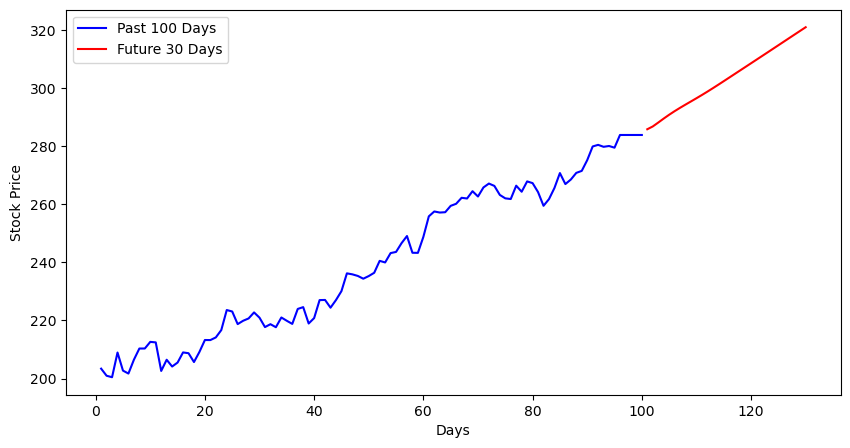

In [ ]:
n_future_days = 30  # Number of days to predict
lst_output = []  # Store predicted values

# Start with the last available time step from test data
current_input = test_data[-time_step:].reshape(1, time_step, 1)

for _ in range(n_future_days):
    # Predict the next day's stock price (scaled value)
    next_prediction_scaled = model.predict(current_input, verbose=0)

    # Store the predicted value
    lst_output.append(next_prediction_scaled[0, 0])

    # Update the input sequence: remove the first value, add the new prediction
    next_input = np.append(current_input[:, 1:, :], next_prediction_scaled.reshape(1, 1, 1), axis=1)
    current_input = next_input

# Convert predictions back to original scale
future_predictions = scaler.inverse_transform(np.array(lst_output).reshape(-1, 1))

# Plot the predictions
plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, 101), scaler.inverse_transform(df1[-100:]), label="Past 100 Days", color="blue")
plt.plot(np.arange(101, 131), future_predictions, label="Future 30 Days", color="red")
plt.xlabel("Days")
plt.ylabel("Stock Price")
plt.legend()
plt.show()
